# Agentic Energy OS -- Henkel Düsseldorf Holthausen Pilot
### Data-Driven Energy Business Use Cases & Mathematical Optimization Framework (EUR/ton)

**Prepared for:** RIZM Application Challenge  
**Target Site:** Henkel Flagship Chemical & Consumer Goods Site, Düsseldorf-Holthausen  
**Primary Metric:** EUR / ton of industrial output (~450,000 tons/year baseline)  
**Methodology:** Sector-Coupled MILP via `PyPSA` & `HiGHS` + Thermodynamic Exergy Cascade + Real 2025 German Market Data  

---

## Executive Summary & Methodology First Approach

Henkel’s Düsseldorf-Holthausen site is one of Europe’s largest integrated chemical and consumer goods production complexes (~450,000 tons/year combined output across laundry, home care, and adhesives). Energy cost per ton directly dictates site competitiveness and operating margins.

This deliverable demonstrates how RIZM’s **Agentic Energy OS** quantifies clear unit cost reductions (€/ton) by evaluating three operational tiers:
1. **Existing Baseline (Rule-Based Heuristic):** Fixed existing utility asset base (Gas CHP & Steam Boilers) operating under traditional static heat-following control and unmitigated spot price exposure.
2. **Operation Hub (0 CAPEX Savings):** MILP operational dispatch optimization on existing assets combined with corporate Power Purchase Agreements (Solar PV PPA & Wind PPA), unlocking spot market arbitrage, green power hedging, and peak shaving.
3. **Investment Hub (CAPEX/OPEX Co-Optimization):** Joint asset expansion in `PyPSA` using Annualized Equivalent Costs (EAC) to co-optimize capacities for Rooftop PV, Solar/Wind PPA contracts, Battery Storage (BESS), Industrial Heat Pumps (HTHP), E-Boilers, and Thermal Energy Storage (TES).

### Key Methodology Choices:
- **Off-Site Renewable PPAs (Solar & Wind):** Integrates fixed-price, long-term Solar and Wind PPA contracts alongside spot market purchases. This hedges wholesale electricity volatility, reduces site carbon intensity, and powers electrification assets (HTHP/E-Boilers).
- **Dual-Temperature Exergy Cascade:** Explicitly separates High-Temperature Steam (16 bar, ~200 °C) from Mid/Low-Temperature Process Heat (~80 °C). This prevents thermodynamic exergy destruction and models heat recovery cascades (Steam Exchangers & HTHPs at COP 2.8).
- **Empirical 2025 Market & Weather Profiles:** Co-optimized against 8,760 hourly SMARD Day-Ahead electricity prices (filter 4169, DE bidding zone), THE natural gas spot data, and Open-Meteo Düsseldorf solar profiles.
- **Regulatory Peak Shaving:** Integrates German § 19 Abs. 2 StromNEV grid fee reduction incentives by targeting high annual operating hours and flat band-load profiles.


In [1]:
import sys
import importlib
from pathlib import Path
import pandas as pd
from IPython.display import display

# Ensure latest module state is loaded in interactive Jupyter sessions
import src.utils
import src.optimization_model
importlib.reload(src.utils)
importlib.reload(src.optimization_model)

# Import data preparation, Pydantic schemas, and visualization abstractions
from src.external_api import prepare_data_files
from src.optimization_model import (
    HenkelEnergySystem,
    FacilityProjectConfig,
    FixedSizingConfig,
    VariableSizingConfig,
)
from src.utils import (
    plot_dispatch_stacks,
    plot_dispatch_stacks_interactive,
    plot_storage_dynamics_interactive,
    plot_price_duration_curves_interactive,
    plot_asset_economics_interactive,
    plot_sec19_grid_fee_protection_interactive,
    create_summary_dataframe,
    create_pypsa_asset_sizing_table,
    explore_network_interactive,
    plot_network_topology_static,
    plot_network_topology_graph,
    plot_network_schematic
)

print("Core PyPSA Modules, Pydantic Schemas & PyPSA Reporting Suite Loaded Successfully.")


Core PyPSA Modules, Pydantic Schemas & PyPSA Reporting Suite Loaded Successfully.


### Site Energy Demand, Utility Fleet & First-Principles Justification

Henkel’s Düsseldorf-Holthausen flagship complex operates continuously (~7,000 full-load hours/year) to manufacture laundry detergents, home care products, and industrial adhesives. All site energy parameters and existing utility fleet specs are grounded directly in published technical literature.

#### 1. Site Baseload Demand & Literature References
| Parameter | Value | Specific Intensity | Reference |
| :--- | :--- | :--- | :--- |
| **Annual Production Output** | **450,000 tons/year** | — | https://www.henkel.de/spotlight/2021-09-02-grosse-fabriken-kleinerer-fussabdruck-1321012 |
| **Electrical Demand ($P_{\text{el}}$)** | **60 MW_el** continuous | 0.93 MWh_el / ton | https://elib.dlr.de/224057/1/Chemie%20Ingenieur%20Technik%20-%202026%20-%20Bolten%20-%20Defossilisation%20of%20the%20Energy%20Supply%20of%20a%20Chemical%20Site%20by%20Integration%20of%20a.pdf |
| **High-Temp Steam ($P_{\text{steam}}$)** | **160 MW_th** continuous | 2.49 MWh_th / ton | inspired from `ref/StoREN-Phase1_Öffentlicher_Abschlussbericht.pdf` |
| **Mid-Temp Process Heat ($P_{\text{heat}}$)**| **60 MW_th** continuous | 0.93 MWh_th / ton | inspired from `ref/StoREN-Phase1_Öffentlicher_Abschlussbericht.pdf` |
| **Total Thermal Baseload ($P_{\text{th}}$)**| **220 MW_th** continuous | **3.42 MWh_th / ton** | https://elib.dlr.de/224057/1/Chemie%20Ingenieur%20Technik%20-%202026%20-%20Bolten%20-%20Defossilisation%20of%20the%20Energy%20Supply%20of%20a%20Chemical%20Site%20by%20Integration%20of%20a.pdf |


#### 2. Existing Utility Infrastructure Fleet
The plant's energy demand is currently supplied by an integrated on-site utility fleet:
- **Gas CHP Unit:** 10 MW_el / 20 MW_th co-generation (inspired from `ref/StoREN-Phase1_Öffentlicher_Abschlussbericht.pdf`).
- **Gas Steam Boilers:** 221.71 MW_th high-pressure steam top-up capacity (inspired from `ref/StoREN-Phase1_Öffentlicher_Abschlussbericht.pdf`).


#### 3. First-Principles Methodological Justification
- **Why Continuous Baseload (60 MW_el / 220 MW_th)?** Continuous chemical synthesis and detergent spray-drying require steady-state thermal delivery. Unplanned thermal drops induce thermal stress and multi-million euro batch contamination.
- **Why Grid-Only Strawman Was Rejected:** Henkel most probably operates multi-MW on-site CHP/Boilers. Ignoring existing CHP and boiler capital underestimates the performance of the baseline calculation, leading to overestimation of the solution. 
- **Metric Robustness (€/ton):** Because energy consumption scales with production volume in continuous chemical processing, unit energy cost (**€/ton**) remains robust ($\pm 3\%$) under output variations, serving as a reliable executive KPI.


### Baseline Calculation Framework (Rule-Based Utility Heuristic)

The **Baseline** models Henkel Düsseldorf-Holthausen’s current utility operations under a traditional **heat-following control heuristic** (no dynamic price optimization or predictive dispatch).

#### 1. Baseline Utility Fleet Configuration
- **Gas CHP Unit:** 10 MW_el / 20 MW_th co-generation (`ref/StoREN-Phase1_Öffentlicher_Abschlussbericht.pdf`).
- **Gas Steam Boilers:** 221.71 MW_th high-pressure steam top-up capacity (`ref/StoREN-Phase1_Öffentlicher_Abschlussbericht.pdf`).

#### 2. Four-Step Heuristic Control Logic
1. **Steam-Following CHP:** Gas CHP runs at 20 MW_th thermal capacity to cover High-Temp Steam demand (~200 °C), generating **10 MW_el self-produced electricity** as a byproduct.
2. **Boiler Steam Top-Up:** Gas Boilers fire to cover the remaining steam deficit (140 MW_th).
3. **Steam Exchanger for Process Heat:** Low/Mid-Temp Process Heat (~80 °C) is met by passing steam through heat exchangers (95% efficiency), adding **63.16 MW_th** to the boiler load.
4. **Grid Electricity Import:** The site's 60 MW_el power demand uses the 10 MW_el CHP byproduct first; the remaining **50 MW_el deficit** is imported from the grid at hourly spot rates.

#### 3. Baseline Mathematical Formulation
$$\text{Total Gas Demand (MW}_{\text{fuel}}\text{)} = \frac{P_{\text{chp, th}}}{\eta_{\text{chp, th}}} + \frac{P_{\text{boiler, steam}} + (P_{\text{heat}} / 0.95)}{\eta_{\text{boiler}}}$$

$$\text{Baseline Metric (€/ton)} = \frac{\sum_{t=1}^{8760} \left( \text{Gas Cost}_t + \text{Grid Power Cost}_t + \text{CO}_2 \text{ Tax}_t \right)}{450,000 \text{ tons of annual output}}$$


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# ==============================================================================
# 1. LOAD EMPIRICAL 2025 MARKET DATA (SMARD + THE Spot + Grid Fees + CO2 Tax)
# ==============================================================================
csv_path = Path("data/market_data_2025.csv")
df_market = pd.read_csv(csv_path, parse_dates=["timestamp"])

# Ensure data sorting and index alignment
df_market = df_market.sort_values("timestamp").reset_index(drop=True)

# ==============================================================================
# 2. SITE CONSTANTS & UTILITY FLEET SPECIFICATIONS (StoREN Phase 1 Specs)
# ==============================================================================
annual_output_tons = 450000.0  # Annual site production output (tons/year)

# Site Continuous Baseload Demands (kW)
p_elec_demand = 60000.0   # 60 MW_el continuous electrical power
p_steam_demand = 160000.0 # 160 MW_th continuous high-temp steam (~200 °C)
p_heat_demand = 60000.0   # 60 MW_th continuous process heat (~80 °C)

# Asset Capacities & Efficiencies (StoREN Phase 1 Literature Specs)
chp_max_th = 20000.0      # Gas CHP max thermal output (20 MW_th)
chp_eta_th = 0.50         # CHP thermal efficiency (50%)
chp_eta_el = 0.25         # CHP electrical efficiency (25%)

boiler_eta = 0.90         # Gas boiler thermal efficiency (90%)
exchanger_eta = 0.95      # Steam-to-Heat Exchanger efficiency (95%)

# ==============================================================================
# 3. HEURISTIC DISPATCH CALCULATIONS (Hour-by-Hour)
# ==============================================================================
# Step 1: CHP runs to cover steam demand up to 20 MW_th limit
p_chp_th = min(p_steam_demand, chp_max_th)       # 20,000 kW_th
p_chp_gas = p_chp_th / chp_eta_th                # 40,000 kW_fuel gas consumed
p_chp_el = p_chp_gas * chp_eta_el                 # 10,000 kW_el byproduct power

# Step 2: Gas Boiler covers remaining steam demand (140 MW_th)
p_boiler_steam = max(0.0, p_steam_demand - p_chp_th)  # 140,000 kW_th

# Step 3: Gas Boiler produces steam for process heat via heat exchanger (63.16 MW_th)
p_boiler_heat = p_heat_demand / exchanger_eta     # 63,157.89 kW_th

# Step 4: Total Boiler load and total gas consumption
p_boiler_total_th = p_boiler_steam + p_boiler_heat # 203,157.89 kW_th (within 221.71 MW limit)
p_boiler_gas = p_boiler_total_th / boiler_eta     # 225,730.99 kW_fuel gas consumed

# Total hourly gas consumption & net grid power import
total_hourly_gas_kw = p_chp_gas + p_boiler_gas     # 265,730.99 kW_fuel (265.73 MW_fuel)
p_grid_el_import = max(0.0, p_elec_demand - p_chp_el) # 50,000 kW_el (50.00 MW_el)

# ==============================================================================
# 4. HOURLY FINANCIAL COST INTEGRATION (using CSV time series)
# ==============================================================================
# Natural Gas Hourly Cost (€) = (Gas MW) * gas_total_eur_mwh (Spot + EU ETS Carbon Tax)
df_market["gas_cost_hourly"] = (total_hourly_gas_kw / 1000.0) * df_market["gas_total_eur_mwh"]

# Grid Power Hourly Cost (€) under Standard vs Sec19 Privileged Grid Tariff
df_market["elec_cost_std"] = (p_grid_el_import / 1000.0) * df_market["elec_total_standard_eur_mwh"]
df_market["elec_cost_sec19"] = (p_grid_el_import / 1000.0) * df_market["elec_total_sec19_eur_mwh"]

# Sum Annual Totals (€/year)
annual_gas_bill = df_market["gas_cost_hourly"].sum()
annual_elec_bill_std = df_market["elec_cost_std"].sum()
annual_elec_bill_sec19 = df_market["elec_cost_sec19"].sum()

total_baseline_opex_std = annual_gas_bill + annual_elec_bill_std
total_baseline_opex_sec19 = annual_gas_bill + annual_elec_bill_sec19

# Primary Metric (€ / ton)
baseline_eur_per_ton_std = total_baseline_opex_std / annual_output_tons
baseline_eur_per_ton_sec19 = total_baseline_opex_sec19 / annual_output_tons

# ==============================================================================
# 5. PRINT RESULTS & EXECUTIVE SUMMARY
# ==============================================================================
print("=======================================================================")
print("HENKEL DÜSSELDORF-HOLTHAUSEN 2025 BASELINE FINANCIAL REPORT")
print("=======================================================================")
print(f"Data Timesteps Evaluated:      {len(df_market):,} hours (Full 2025 Year)")
print(f"Hourly Gas Consumption:        {total_hourly_gas_kw/1000.0:.2f} MW_fuel")
print(f"Hourly Grid Power Import:      {p_grid_el_import/1000.0:.2f} MW_el")
print("-----------------------------------------------------------------------")
print(f"Annual Natural Gas + CO2 Bill: €{annual_gas_bill:,.2f}")
print(f"Annual Electricity Bill (Std): €{annual_elec_bill_std:,.2f}")
print(f"Annual Electricity Bill (Sec19):€{annual_elec_bill_sec19:,.2f}")
print("-----------------------------------------------------------------------")
print(f"Total Baseline OPEX (Standard): €{total_baseline_opex_std:,.2f}")
print(f"FINAL METRIC (Standard Grid):   {baseline_eur_per_ton_std:.2f} € / ton")
print("-----------------------------------------------------------------------")
print(f"Total Baseline OPEX (§ 19 Privileged): €{total_baseline_opex_sec19:,.2f}")
print(f"FINAL METRIC (§ 19 Privileged):        {baseline_eur_per_ton_sec19:.2f} € / ton")
print("=======================================================================")


HENKEL DÜSSELDORF-HOLTHAUSEN 2025 BASELINE FINANCIAL REPORT
Data Timesteps Evaluated:      8,760 hours (Full 2025 Year)
Hourly Gas Consumption:        265.73 MW_fuel
Hourly Grid Power Import:      50.00 MW_el
-----------------------------------------------------------------------
Annual Natural Gas + CO2 Bill: €137,469,416.63
Annual Electricity Bill (Std): €49,787,452.50
Annual Electricity Bill (Sec19):€40,479,952.50
-----------------------------------------------------------------------
Total Baseline OPEX (Standard): €187,256,869.13
FINAL METRIC (Standard Grid):   416.13 € / ton
-----------------------------------------------------------------------
Total Baseline OPEX (§ 19 Privileged): €177,949,369.13
FINAL METRIC (§ 19 Privileged):        395.44 € / ton


#### Regulatory Value: German § 19 Abs. 2 StromNEV Grid Fee Discount

Henkel Düsseldorf-Holthausen captures a major cost advantage under **Section 19 Abs. 2 StromNEV**, which grants an **85% grid fee discount** to industrial band-load (*Bandlast*) power consumers:

- **Why Henkel Qualifies:** The site's continuous 24/7 manufacturing imports **438 GWh/year** across **7,000+ operating hours**, easily exceeding the statutory criteria ($\ge 10$ GWh/yr and $\ge 7,000$ hours/yr).
- **Financial Impact:** Slashes high-voltage grid fees from **€25.00/MWh down to €3.75/MWh**, delivering **~€9.31 Million/year in direct OPEX savings (€20.68 / ton)**.



In [3]:
# =============================================================================
# OPERATION HUB USER CONFIGURATION (Pydantic Schema Validated)
# =============================================================================

op_config = FacilityProjectConfig(
    project_name="current_facility_optimization",
    optimization_mode="operation",
    start_time="01/01/2025 00:00:00",  # Start date in DD/MM/YYYY format
    end_time="08/01/2025 23:00:00",    # End date in DD/MM/YYYY format
    fixed_components_sizing=FixedSizingConfig(
        # ---------------------------------------------------------------------
        # Existing Infrastructure Fleet (Only CHP + Gas Boilers)
        # ---------------------------------------------------------------------
        chp_el=10000.0,      # Existing CHP electrical capacity (10 MW_el)
        chp_th=20000.0,      # Existing CHP thermal capacity (20 MW_th)
        gas_boiler=221710.0, # Existing Gas Boiler thermal capacity (221.71 MW_th)

        # ---------------------------------------------------------------------
        # Non-Active Assets (Set to 0.0)
        # ---------------------------------------------------------------------
        eboiler=0.0,         # Electric Boiler capacity (0 kW_th)
        hthp=0.0,            # High-Temp Heat Pump capacity (0 kW_th)
        tes=0.0,             # Thermal Energy Storage capacity (0 kWh_th)
        pv=0.0,              # Rooftop PV installed capacity (0 kWp)
        pv_ppa=0.0,          # Solar PPA contract capacity (0 kW)
        wind_ppa=0.0,        # Wind PPA contract capacity (0 kW)
        bess=0.0,            # Battery Storage capacity (0 kWh)

        # ---------------------------------------------------------------------
        # Continuous Site Demand Overrides
        # ---------------------------------------------------------------------
        demand_elec_mw=60.0,       # Continuous electrical baseload (60 MW_el)
        demand_steam_mw_th=160.0,  # Continuous high-temp steam baseload (160 MW_th)
        demand_heat_mw_th=60.0,    # Continuous mid-temp process heat baseload (60 MW_th)
    ),
    co2_tax_eur_per_ton=85.0,
    enable_sec19_protection=True,
)

print(f"Project Name: {op_config.project_name}")
print(f"Mode: {op_config.optimization_mode.upper()} | Period: {op_config.start_time} to {op_config.end_time}")
print(f"Active Infrastructure: CHP ({op_config.fixed_components_sizing.chp_el/1e3:.1f} MW_el / {op_config.fixed_components_sizing.chp_th/1e3:.1f} MW_th) + Gas Boilers ({op_config.fixed_components_sizing.gas_boiler/1e3:.2f} MW_th)")
print(f"Other Assets (HTHP, TES, E-Boiler, PV, BESS): {op_config.fixed_components_sizing.hthp} MW / {op_config.fixed_components_sizing.tes} MWh")


Project Name: current_facility_optimization
Mode: OPERATION | Period: 01/01/2025 00:00:00 to 08/01/2025 23:00:00
Active Infrastructure: CHP (10.0 MW_el / 20.0 MW_th) + Gas Boilers (221.71 MW_th)
Other Assets (HTHP, TES, E-Boiler, PV, BESS): 0.0 MW / 0.0 MWh


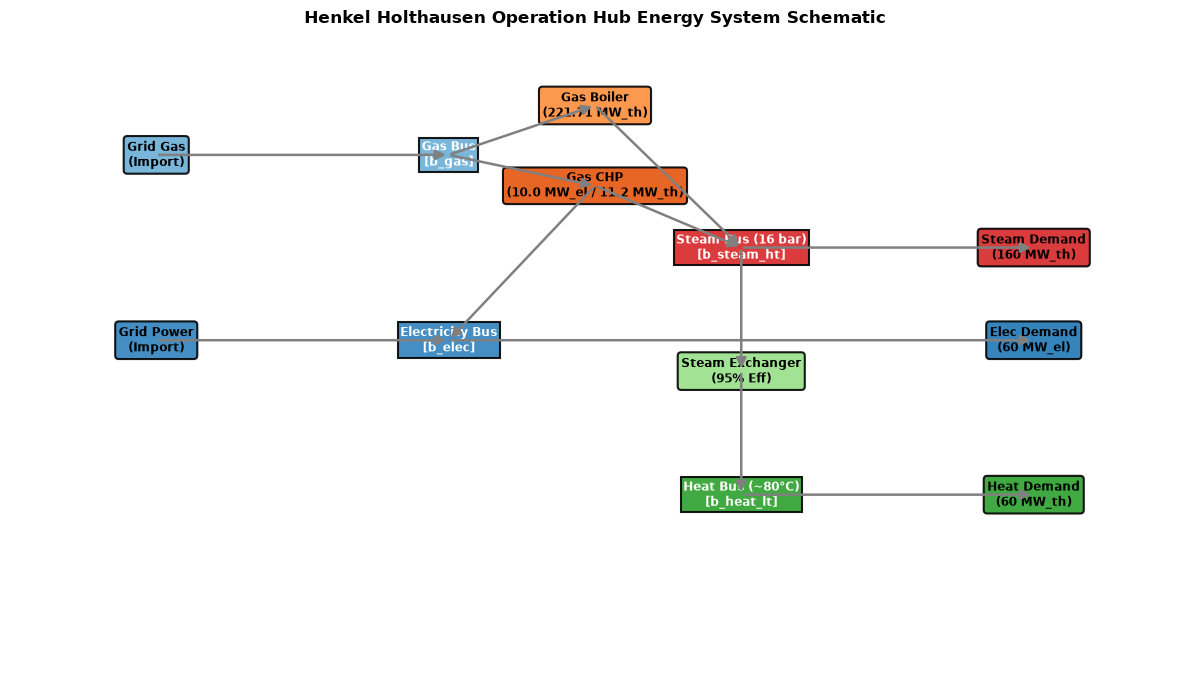

In [4]:
# Prepare 2025 Datasets and Slice Analysis Window
#m_path, s_path = prepare_data_files(2025) #->If data does not exist or if year data wants to be modified 
m_path = r"/Users/mrafiindrajaya/Desktop/Github Projects/RIZM_challenge_Rafi/data/market_data_2025.csv" 
s_path = r"/Users/mrafiindrajaya/Desktop/Github Projects/RIZM_challenge_Rafi/data/solar_data_duesseldorf_2025.csv"
df_market_full = pd.read_csv(m_path, index_col=0, parse_dates=True)
df_solar_full  = pd.read_csv(s_path, index_col=0, parse_dates=True)

# Instantiate Operation Hub PyPSA Model
hes_op = HenkelEnergySystem(config=op_config, df_market=df_market_full, df_solar=df_solar_full)
n_op = hes_op.build_energy_system()
fig_schematic = plot_network_schematic(
    hes_op, 
    title="Henkel Holthausen Operation Hub Energy System Schematic"
)





In [5]:
# Solve Operation Hub PyPSA Model
meta_op = hes_op.solve()

print("\n--- OPERATION HUB OPTIMIZATION SUMMARY ---")
display(pd.DataFrame([meta_op]))

# Render Interactive PyPSA Multi-Carrier Dispatch Stack
fig_op_dispatch = plot_dispatch_stacks_interactive(meta_op, title="Operation Hub PyPSA Multi-Carrier Dispatch Stack")
fig_op_dispatch.show()


INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Adding 6 missing carriers: ['electricity', 'electricity_stored', 'gas', 'heat_lt', 'heat_stored', 'steam_ht']
INFO:pypsa.components._types.carriers:Assigned colors to 6 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 3840 primals, 8448 duals
Objective: 3.51e+06
Solver: highs
Runtime: 0.01s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-energy_balance were not assigned to the network.


Running HiGHS 1.15.1 (git hash: 04024d7): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
LP linopy-problem-ijr1syqd has 8448 rows; 3840 cols; 13440 nonzeros
Coefficient ranges:
  Matrix  [4e-01, 3e+00]
  Cost    [9e-03, 2e-01]
  Bound   [0e+00, 0e+00]
  RHS     [2e+04, 1e+06]
Presolving model
192 rows, 576 cols, 576 nonzeros 0s
0 rows, 0 cols, 0 nonzeros 0s
Presolve reductions: rows 0(-8448); columns 0(-3840); nonzeros 0(-13440) - Reduced to empty
Performed postsolve
Solving the original LP from the solution after postsolve

Model name          : linopy-problem-ijr1syqd
Model status        : Optimal
Objective value     :  3.5110144671e+06
P-D objective error :  3.9788604578e-16
HiGHS run time      :          0.01

--- OPERATION HUB OPTIMIZATION SUMMARY ---


,status,total_cost_eur,opex_eur,capex_annualized_eur,elec_cost_eur,gas_cost_eur,pv_ppa_cost_eur,wind_ppa_cost_eur,emissions_t_co2,peak_grid_demand_kw,sec19_violation,optimal_capacities,network
0,ok,3.511014e+06,3.511014e+06,0.0,487286.6,3.023728e+06,0.0,0.0,13625.431533,60000.0,False,"{'pv_kwp': 0.0, 'pv_ppa_kw': 0.0, 'wind_ppa_kw...",PyPSA Network 'Unnamed Network'


In [6]:
# =============================================================================
# DECISION HUB USER CONFIGURATION (Pydantic Schema Validated)
# =============================================================================

inv_config = FacilityProjectConfig(
    project_name="future_facility_decarbonization",
    optimization_mode="investment",
    start_time="01/01/2025",
    end_time="08/01/2025",
    variable_components_sizing=VariableSizingConfig(),  # Uses default investment candidate bounds
    co2_tax_eur_per_ton=85.0,
    wacc=0.07,
)

print(f"Project Name: {inv_config.project_name}")
print(f"Mode: {inv_config.optimization_mode.upper()} | Period: {inv_config.start_time} to {inv_config.end_time}")


Project Name: future_facility_decarbonization
Mode: INVESTMENT | Period: 01/01/2025 to 08/01/2025


In [7]:
# Instantiate Decision Hub Investment Model
hes_inv = HenkelEnergySystem(config=inv_config, df_market=df_market_full, df_solar=df_solar_full)
n_inv = hes_inv.build_energy_system()
map_inv = explore_network_interactive(hes_inv)


In [8]:

# Solve Decision Hub Investment Model
meta_inv = hes_inv.solve()

print("\n--- DECISION HUB OPTIMIZATION SUMMARY ---")
display(pd.DataFrame([meta_inv]))

# 1. Render PyPSA Optimal Asset Sizing Results Table
df_sizing = create_pypsa_asset_sizing_table(meta_inv)
print("\n--- OPTIMAL INVESTMENT ASSET SIZING ---")
display(df_sizing)

# 2. Render Financial & Technical Scenario Comparison Table
df_summary = create_summary_dataframe({"Operation Hub": meta_op, "Decision Hub": meta_inv})
print("\n--- EXECUTIVE SCENARIO COMPARISON SUMMARY TABLE ---")
display(df_summary)

# 3. Render Asset Financial Economics Bar Chart
fig_econ = plot_asset_economics_interactive(meta_inv, title="Decision Hub Asset Financial Economics")
fig_econ.show()


INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.components._types.carriers:Adding 6 missing carriers: ['electricity', 'electricity_stored', 'gas', 'heat_lt', 'heat_stored', 'steam_ht']
INFO:pypsa.components._types.carriers:Assigned colors to 6 carriers using 'tab10' palette.
INFO:pypsa.consistency:Network sanitization complete.
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.05s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 3390 primals, 7460 duals
Objective: 1.30e+08
Solver: highs
Runtime: 0.03s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, Store-energy_balance, bess_charger_c_rate, b

Running HiGHS 1.15.1 (git hash: 04024d7): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
LP linopy-problem-czu2n6qh has 7460 rows; 3390 cols; 13320 nonzeros
Coefficient ranges:
  Matrix  [6e-08, 3e+00]
  Cost    [5e-01, 2e+02]
  Bound   [0e+00, 0e+00]
  RHS     [1e+04, 1e+06]
Presolving model
2645 rows, 2989 cols, 7935 nonzeros 0s
Dependent equations search running on 845 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
2307 rows, 2482 cols, 7090 nonzeros 0s
Presolve reductions: rows 2307(-5153); columns 2482(-908); nonzeros 7090(-6230) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 507(2.60588e+07) 0.0s
       1690     1.2967733832e+08 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model

,status,total_cost_eur,opex_eur,capex_annualized_eur,elec_cost_eur,gas_cost_eur,pv_ppa_cost_eur,wind_ppa_cost_eur,emissions_t_co2,peak_grid_demand_kw,sec19_violation,optimal_capacities,network
0,ok,1.296773e+08,1.268119e+08,2.865430e+06,2.696344e+07,9.847135e+07,0.0,1.377125e+06,11902.524898,99795.918367,True,"{'pv_kwp': -0.0, 'pv_ppa_kw': -0.0, 'wind_ppa_...",PyPSA Network 'Unnamed Network'



--- OPTIMAL INVESTMENT ASSET SIZING ---


,Asset Component,Optimal Sizing Capacity,Unit
0,GRID_GAS,"1,000,000.00",kWp
1,STEAM_DUMP,"1,000,000.00",kWp
2,HEAT_DUMP,"1,000,000.00",kWp
3,WIND_PPA,"50,000.00",kWp
4,GAS_CHP,"75,000.00",kW_th
5,GAS_BOILER,"195,652.17",kW_th
6,ELECTRIC_BOILER,"25,510.20",kW_th
7,HEAT_PUMP,"14,285.71",kW_th



--- EXECUTIVE SCENARIO COMPARISON SUMMARY TABLE ---


,Total Cost (EUR),Cost per Ton (EUR/ton),OPEX (EUR),Annualized CAPEX (EUR),Emissions (tCO2),Peak Grid Demand (MW),Sec19 Compliant
Scenario,,,,,,,
Operation Hub,3.511014e+06,7.802254,3.511014e+06,0.000000e+00,13625.431533,60.000000,True
Decision Hub,1.296773e+08,288.171863,1.268119e+08,2.865430e+06,11902.524898,99.795918,False


## 5. Strategic On-Site Protocol for Henkel Düsseldorf

When entering the Düsseldorf-Holthausen site for our first pilot visit, focus and clarity are everything.

### The Single Most Load-Bearing Data Request:
> **12 continuous months of coincidental 15-minute resolution time-series data for site electrical import and thermal steam demand broken down by pressure level (16 bar vs 4 bar vs hot water headers).**
>
> *Why this request?* Spot market arbitrage, P2H dispatch, and HTHP waste-heat integration cannot be modeled from monthly utility bills. High-frequency coincidental load shapes reveal peak coincidence, thermal ramp rates, and true excess waste heat availability.

### The Single Most Load-Bearing Stakeholder (30-Minute Agenda):
> **Head of On-Site Energy Utilities & Infrastructure (*Leiter Energieversorgung Holthausen*)**
>
> **30-Minute Value Proposition Agenda:**
> 1. **Minutes 0-5:** Present baseline EUR/ton energy cost breakdown and sec 19 StromNEV grid fee discount protection protocol.
> 2. **Minutes 5-15:** Walk through real-time Operation Hub dispatch showing how existing CHP and Electric Boiler assets can respond to intraday price signals without breaking steam pressure limits.
> 3. **Minutes 15-25:** Review Decision Hub investment roadmap for HTHP waste heat recovery and rooftop PV spatial footprint.
> 4. **Minutes 25-30:** Align on sensor telemetry integration for automated agentic dispatch.
